<a href="https://colab.research.google.com/github/tahura98/fake-news-detection_Using-NLP_Code/blob/main/NLP_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import os
import re
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

try:
    import shap
    SHAP_AVAILABLE = True
except:
    SHAP_AVAILABLE = False

In [ ]:
# STEP 2: REPRODUCIBILITY + DEVICE
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# STEP 3: LOAD DATASET FROM YOUR EXACT PATH
DATA_PATH = "/content/fake_true_data.xlsx"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found at: {DATA_PATH}")

xls = pd.ExcelFile(DATA_PATH)
print("Available sheets:", xls.sheet_names)

preferred_sheet = "merged_fake_true_15000"
if preferred_sheet in xls.sheet_names:
    SHEET_NAME = preferred_sheet
else:
    SHEET_NAME = xls.sheet_names[0]

print("Using sheet:", SHEET_NAME)

df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print("Original shape:", df.shape)
print("Original columns:", df.columns.tolist())
df.head()

Available sheets: ['merged_fake_true_15000']
Using sheet: merged_fake_true_15000
Original shape: (14770, 120)
Original columns: ['title', 'text', 'subject', 'label', 'source', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31', 'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43', 'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47', 'Unnamed: 48', 'Unnamed: 49', 'Unnamed: 50', 'Unnamed: 51', 'Unnamed: 52', 'Unnamed: 53', 'Unnamed: 54', 'Unnamed: 55', 'Unnamed: 56', 'Unnamed: 57', 'Unnamed: 58', 'Unnamed: 59', 'Unn

,title,text,subject,label,source,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 110,Unnamed: 111,Unnamed: 112,Unnamed: 113,Unnamed: 114,Unnamed: 115,Unnamed: 116,Unnamed: 117,Unnamed: 118,Unnamed: 119
0,No Class Michelle Obama Takes Several Swipes A...,No class and no decorum! The always bitter Mic...,left-news,0,fake,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
1,"'Joe the Plumber' praises Trump, cites his 'be...","HOLLAND, Ohio (Reuters) - “Joe the Plumber,” t...",politicsNews,1,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
2,“CHICKEN LITTLE” AL GORE Uses Fear and the Bib...,Former VP Al Gore told ABC s George Stephanopo...,politics,0,fake,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
3,Zimbabwe's state mouthpiece captures fall of F...,JOHANNESBURG (Reuters) - Zimbabwe s longstandi...,worldnews,1,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN
4,France's Macron says world is losing battle ag...,PARIS (Reuters) - French President Emmanuel Ma...,worldnews,1,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN


In [ ]:
# STEP 4: CLEAN COLUMNS
df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed", regex=True)]

required_cols = ['title', 'text', 'subject', 'label', 'source']
available_cols = [c for c in required_cols if c in df.columns]
df = df[available_cols].copy()

print("Columns after cleanup:", df.columns.tolist())
print("Shape after cleanup:", df.shape)

Columns after cleanup: ['title', 'text', 'subject', 'label', 'source']
Shape after cleanup: (14770, 5)


In [ ]:
# STEP 5: HANDLE MISSING VALUES
for col in ['title', 'text', 'subject', 'source']:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str)

df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df[df['label'].isin([0, 1])].copy()
df = df[df['text'].str.strip() != ""].copy()

print("Shape after filtering:", df.shape)
print(df['label'].value_counts())

Shape after filtering: (14746, 5)
label
1.0    7494
0.0    7252
Name: count, dtype: int64


In [ ]:
# STEP 6: TEXT CLEANING
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s\.\,\!\?\-]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['title_clean'] = df['title'].apply(clean_text) if 'title' in df.columns else ""
df['text_clean'] = df['text'].apply(clean_text) if 'text' in df.columns else ""
df['subject_clean'] = df['subject'].apply(clean_text) if 'subject' in df.columns else ""

In [ ]:
# STEP 7: UNIQUE CONTEXT-AWARE TEXT BUILDING
df['combined_text'] = (
    "[TITLE] " + df['title_clean'] +
    " [SUBJECT] " + df['subject_clean'] +
    " [BODY] " + df['text_clean']
)

df = df[df['combined_text'].str.strip() != ""].copy()

print("Final usable shape:", df.shape)
df[['combined_text', 'label']].head()

Final usable shape: (14746, 9)


,combined_text,label
0,[TITLE] no class michelle obama takes several ...,0.0
1,"[TITLE] joe the plumber praises trump, cites h...",1.0
2,[TITLE] chicken little al gore uses fear and t...,0.0
3,[TITLE] zimbabwe s state mouthpiece captures f...,1.0
4,[TITLE] france s macron says world is losing b...,1.0


In [ ]:
# STEP 8: LABEL MAP
label_map = {
    0: "Fake",
    1: "Real"
}

X = df['combined_text']
y = df['label'].astype(int)

print("Label map:", label_map)

Label map: {0: 'Fake', 1: 'Real'}


In [ ]:
# STEP 9: TRAIN / VALIDATION / TEST SPLIT
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 10322
Validation size: 2212
Test size: 2212


In [ ]:
# STEP 10: TF-IDF FEATURES
tfidf_word = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=40000,
    sublinear_tf=True,
    min_df=2
)

tfidf_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    max_features=30000,
    sublinear_tf=True,
    min_df=2
)

X_train_word = tfidf_word.fit_transform(X_train)
X_val_word = tfidf_word.transform(X_val)
X_test_word = tfidf_word.transform(X_test)

X_train_char = tfidf_char.fit_transform(X_train)
X_val_char = tfidf_char.transform(X_val)
X_test_char = tfidf_char.transform(X_test)

X_train_tfidf = hstack([X_train_word, X_train_char])
X_val_tfidf = hstack([X_val_word, X_val_char])
X_test_tfidf = hstack([X_test_word, X_test_char])

print("TF-IDF train shape:", X_train_tfidf.shape)

TF-IDF train shape: (10322, 70000)


In [ ]:
# STEP 11: CLASS WEIGHTS
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(1.0167454688731286), np.int64(1): np.float64(0.9837971788028974)}


In [ ]:
# STEP 12: BASELINE MODEL 1 - TF-IDF + LINEAR SVM
svm_model = LinearSVC(
    class_weight=class_weight_dict,
    C=1.0,
    max_iter=7000,
    random_state=SEED
)

svm_model.fit(X_train_tfidf, y_train)

y_val_pred_svm = svm_model.predict(X_val_tfidf)
print("Validation Results (SVM)\n")
print(classification_report(y_val, y_val_pred_svm, target_names=['Fake', 'Real'], digits=4))

y_test_pred_svm = svm_model.predict(X_test_tfidf)
print("Test Results (SVM)\n")
print(classification_report(y_test, y_test_pred_svm, target_names=['Fake', 'Real'], digits=4))

svm_acc = accuracy_score(y_test, y_test_pred_svm)
svm_f1 = f1_score(y_test, y_test_pred_svm, average='weighted')

print("SVM Accuracy:", round(svm_acc, 4))
print("SVM Weighted F1:", round(svm_f1, 4))

Validation Results (SVM)

              precision    recall  f1-score   support

        Fake     0.9982    0.9991    0.9986      1088
        Real     0.9991    0.9982    0.9987      1124

    accuracy                         0.9986      2212
   macro avg     0.9986    0.9987    0.9986      2212
weighted avg     0.9986    0.9986    0.9986      2212

Test Results (SVM)

              precision    recall  f1-score   support

        Fake     0.9991    0.9963    0.9977      1088
        Real     0.9965    0.9991    0.9978      1124

    accuracy                         0.9977      2212
   macro avg     0.9978    0.9977    0.9977      2212
weighted avg     0.9977    0.9977    0.9977      2212

SVM Accuracy: 0.9977
SVM Weighted F1: 0.9977


In [ ]:
# STEP 13: BASELINE MODEL 2 - LOGISTIC REGRESSION
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=4000,
    C=1.0,
    random_state=SEED,
    n_jobs=-1
)

lr_model.fit(X_train_tfidf, y_train)

y_val_pred_lr = lr_model.predict(X_val_tfidf)
print("Validation Results (Logistic Regression)\n")
print(classification_report(y_val, y_val_pred_lr, target_names=['Fake', 'Real'], digits=4))

y_test_pred_lr = lr_model.predict(X_test_tfidf)
print("Test Results (Logistic Regression)\n")
print(classification_report(y_test, y_test_pred_lr, target_names=['Fake', 'Real'], digits=4))

lr_acc = accuracy_score(y_test, y_test_pred_lr)
lr_f1 = f1_score(y_test, y_test_pred_lr, average='weighted')

print("LogReg Accuracy:", round(lr_acc, 4))
print("LogReg Weighted F1:", round(lr_f1, 4))

Validation Results (Logistic Regression)

              precision    recall  f1-score   support

        Fake     0.9954    0.9972    0.9963      1088
        Real     0.9973    0.9956    0.9964      1124

    accuracy                         0.9964      2212
   macro avg     0.9964    0.9964    0.9964      2212
weighted avg     0.9964    0.9964    0.9964      2212

Test Results (Logistic Regression)

              precision    recall  f1-score   support

        Fake     0.9972    0.9917    0.9945      1088
        Real     0.9920    0.9973    0.9947      1124

    accuracy                         0.9946      2212
   macro avg     0.9946    0.9945    0.9946      2212
weighted avg     0.9946    0.9946    0.9946      2212

LogReg Accuracy: 0.9946
LogReg Weighted F1: 0.9946


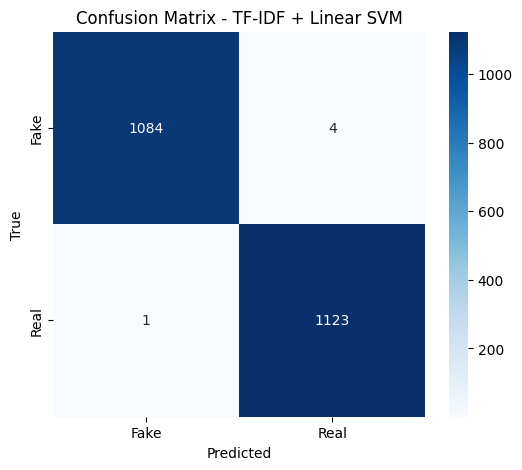

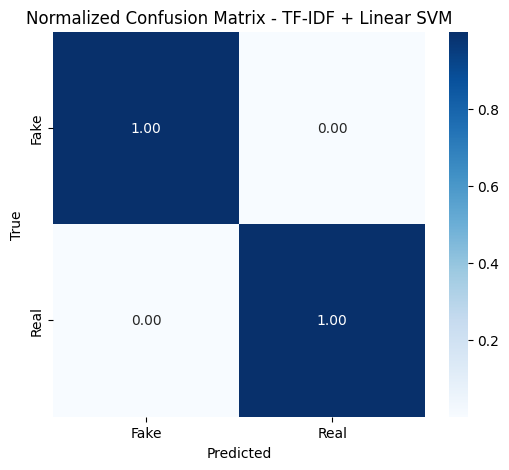

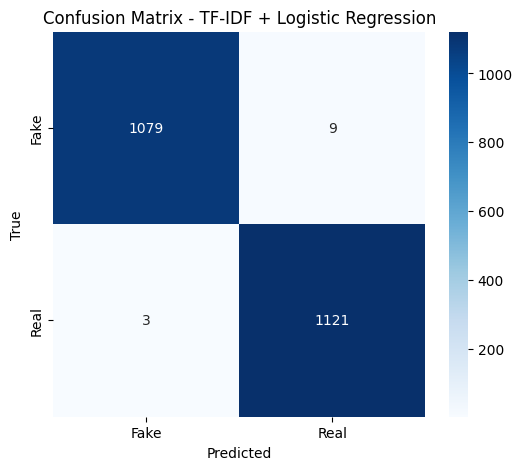

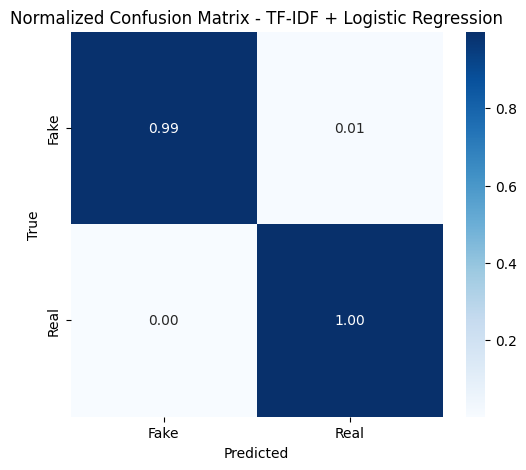

In [ ]:
# STEP 14: CONFUSION MATRIX FUNCTION
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    labels = ['Fake', 'Real']

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

    plt.figure(figsize=(6,5))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Normalized Confusion Matrix - {title}")
    plt.show()

plot_confusion_matrix(y_test, y_test_pred_svm, "TF-IDF + Linear SVM")
plot_confusion_matrix(y_test, y_test_pred_lr, "TF-IDF + Logistic Regression")

In [ ]:
# STEP 15: ROBERTA TOKENIZER
MODEL_NAME = "roberta-base"
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 3
LR = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# STEP 16: DATASET CLASS
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = FakeNewsDataset(X_train.tolist(), y_train.tolist(), tokenizer, MAX_LEN)
val_dataset = FakeNewsDataset(X_val.tolist(), y_val.tolist(), tokenizer, MAX_LEN)
test_dataset = FakeNewsDataset(X_test.tolist(), y_test.tolist(), tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# STEP 17: LOAD ROBERTA MODEL
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    hidden_dropout_prob=0.2,
    attention_probs_dropout_prob=0.2
).to(device)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# STEP 18: TRAINING AND EVALUATION FUNCTIONS
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    preds_all = []
    labels_all = []

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        preds_all.extend(preds)
        labels_all.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average='weighted')

    return avg_loss, acc, f1


def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds_all = []
    labels_all = []
    probs_all = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
            preds_all.extend(preds)
            labels_all.extend(labels.detach().cpu().numpy())
            probs_all.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average='weighted')

    return avg_loss, acc, f1, np.array(preds_all), np.array(labels_all), np.array(probs_all)

In [ ]:
# STEP 19: FAST ROBERTA TRAINING SETUP

FAST_MODEL_NAME = "distilroberta-base"
MAX_LEN = 128
BATCH_SIZE = 4
EPOCHS = 2
LR = 2e-5
PATIENCE = 1
MAX_TRAIN_BATCHES = 150
MAX_VAL_BATCHES = 40
MAX_TEST_BATCHES = 60

print("Using fast model:", FAST_MODEL_NAME)
print("MAX_LEN:", MAX_LEN)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)

Using fast model: distilroberta-base
MAX_LEN: 128
BATCH_SIZE: 4
EPOCHS: 2


In [ ]:
# RESET IMPORT BLOCK
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
# STEP 20: REBUILD TOKENIZER + DATALOADERS FOR FAST TRAINING
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(FAST_MODEL_NAME)

class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = FakeNewsDataset(X_train.tolist(), y_train.tolist(), tokenizer, MAX_LEN)
val_dataset   = FakeNewsDataset(X_val.tolist(), y_val.tolist(), tokenizer, MAX_LEN)
test_dataset  = FakeNewsDataset(X_test.tolist(), y_test.tolist(), tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 2581
Val batches: 553
Test batches: 553


In [ ]:
# STEP 21: LOAD FAST MODEL + LOSS + OPTIMIZER + SCHEDULER
import torch
import torch.nn as nn
from transformers import get_linear_schedule_with_warmup

model = AutoModelForSequenceClassification.from_pretrained(
    FAST_MODEL_NAME,
    num_labels=2
).to(device)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

effective_train_steps = min(len(train_loader), MAX_TRAIN_BATCHES)
total_steps = effective_train_steps * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.1 * total_steps)),
    num_training_steps=total_steps
)

print("Model loaded:", FAST_MODEL_NAME)
print("Effective train steps per epoch:", effective_train_steps)
print("Total training steps:", total_steps)

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilroberta-base
Effective train steps per epoch: 150
Total training steps: 300


In [ ]:
# STEP 22: FAST TRAIN / EVAL FUNCTIONS
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

def train_one_epoch_fast(model, loader, optimizer, scheduler, criterion, device, max_batches=None):
    model.train()
    total_loss = 0.0
    preds_all = []
    labels_all = []
    processed_batches = 0

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        processed_batches += 1

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        preds_all.extend(preds)
        labels_all.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / max(processed_batches, 1)
    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average='weighted')

    return avg_loss, acc, f1


def evaluate_model_fast(model, loader, criterion, device, max_batches=None):
    model.eval()
    total_loss = 0.0
    preds_all = []
    labels_all = []
    probs_all = []
    processed_batches = 0

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            if max_batches is not None and batch_idx >= max_batches:
                break

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1)

            total_loss += loss.item()
            processed_batches += 1

            preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
            preds_all.extend(preds)
            labels_all.extend(labels.detach().cpu().numpy())
            probs_all.extend(probs.detach().cpu().numpy())

    avg_loss = total_loss / max(processed_batches, 1)
    acc = accuracy_score(labels_all, preds_all)
    f1 = f1_score(labels_all, preds_all, average='weighted')

    return avg_loss, acc, f1, np.array(preds_all), np.array(labels_all), np.array(probs_all)

In [ ]:
# STEP 23: FAST TRAINING LOOP
best_val_f1 = 0.0
save_path = "best_roberta_fake_news.pt"
patience_counter = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_acc, train_f1 = train_one_epoch_fast(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        device=device,
        max_batches=MAX_TRAIN_BATCHES
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")

    val_loss, val_acc, val_f1, val_preds, val_labels, val_probs = evaluate_model_fast(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        max_batches=MAX_VAL_BATCHES
    )

    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), save_path)
        print("Best model saved.")

    else:
        patience_counter += 1
        print(f"No improvement. Patience counter: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break


Epoch 1/2
Train Loss: 0.2379 | Train Acc: 0.8667 | Train F1: 0.8662
Val   Loss: 0.0440 | Val   Acc: 0.9938 | Val   F1: 0.9938
Best model saved.

Epoch 2/2
Train Loss: 0.0107 | Train Acc: 0.9983 | Train F1: 0.9983
Val   Loss: 0.0489 | Val   Acc: 0.9938 | Val   F1: 0.9938
No improvement. Patience counter: 1/1
Early stopping triggered.


In [ ]:
# STEP 24: TEST BEST MODEL
from sklearn.metrics import classification_report

model.load_state_dict(torch.load(save_path, map_location=device))

test_loss, test_acc, test_f1, test_preds, test_labels, test_probs = evaluate_model_fast(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    max_batches=MAX_TEST_BATCHES
)

print("\nFinal Test Results (Fast Transformer Model)\n")
print(classification_report(
    test_labels,
    test_preds,
    target_names=['Fake', 'Real'],
    digits=4
))

print("Test Accuracy:", round(test_acc, 4))
print("Test Weighted F1:", round(test_f1, 4))


Final Test Results (Fast Transformer Model)

              precision    recall  f1-score   support

        Fake     0.9752    0.9916    0.9833       119
        Real     0.9916    0.9752    0.9833       121

    accuracy                         0.9833       240
   macro avg     0.9834    0.9834    0.9833       240
weighted avg     0.9835    0.9833    0.9833       240

Test Accuracy: 0.9833
Test Weighted F1: 0.9833


In [ ]:
#extra
report_fast = classification_report(
    test_labels,
    test_preds,
    target_names=['Fake', 'Real'],
    digits=4,
    output_dict=True
)

fast_report_df = pd.DataFrame(report_fast).transpose()
print(fast_report_df)
fast_report_df.to_csv("fast_transformer_classification_report.csv")

              precision    recall  f1-score     support
Fake           0.975207  0.991597  0.983333  119.000000
Real           0.991597  0.975207  0.983333  121.000000
accuracy       0.983333  0.983333  0.983333    0.983333
macro avg      0.983402  0.983402  0.983333  240.000000
weighted avg   0.983470  0.983333  0.983333  240.000000


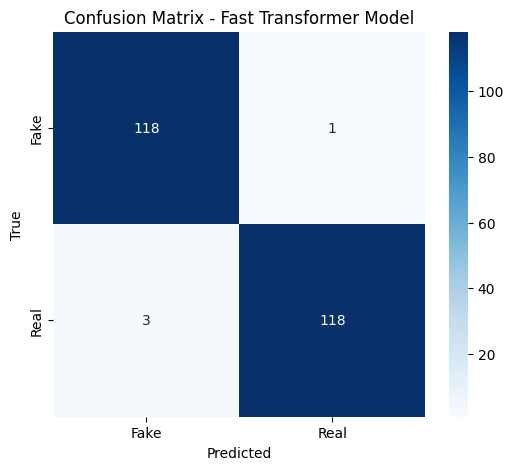

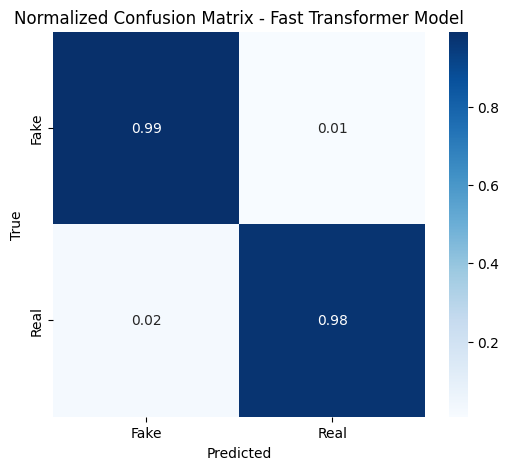

In [ ]:
# STEP 25: CONFUSION MATRIX
plot_confusion_matrix(test_labels, test_preds, "Fast Transformer Model")

In [ ]:
# STEP 26: EXPECTED CALIBRATION ERROR (ECE)
def expected_calibration_error(y_true, probs, n_bins=10):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == y_true)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]

        in_bin = (confidences > lower) & (confidences <= upper)
        prop_in_bin = np.mean(in_bin)

        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(accuracies[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin

    return ece

ece_score = expected_calibration_error(test_labels, test_probs, n_bins=10)
print("ECE Score:", round(ece_score, 4))

ECE Score: 0.0161


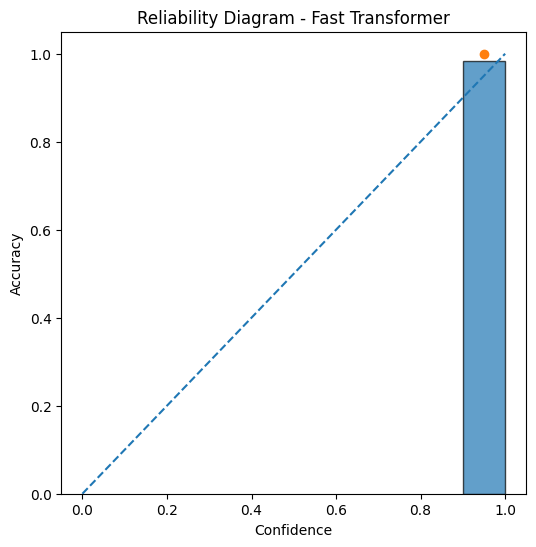

In [ ]:
# STEP 27: RELIABILITY DIAGRAM
import matplotlib.pyplot as plt

def plot_reliability_diagram(y_true, probs, n_bins=10):
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = (predictions == y_true)

    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_accs = []
    bin_confs = []

    for i in range(n_bins):
        lower = bin_boundaries[i]
        upper = bin_boundaries[i + 1]
        in_bin = (confidences > lower) & (confidences <= upper)

        if np.sum(in_bin) > 0:
            bin_centers.append((lower + upper) / 2)
            bin_accs.append(np.mean(accuracies[in_bin]))
            bin_confs.append(np.mean(confidences[in_bin]))

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.bar(bin_centers, bin_accs, width=1/n_bins, alpha=0.7, edgecolor='black')
    plt.plot(bin_centers, bin_confs, marker='o')
    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability Diagram - Fast Transformer")
    plt.show()

plot_reliability_diagram(test_labels, test_probs, n_bins=10)

In [ ]:
# STEP 28: MONTE CARLO DROPOUT
def enable_mc_dropout(model):
    for module in model.modules():
        if module.__class__.__name__.startswith("Dropout"):
            module.train()

def mc_dropout_predict(model, loader, mc_passes=10, device='cpu', max_batches=None):
    model.eval()
    enable_mc_dropout(model)

    all_preds = []
    all_labels = []
    all_mean_probs = []
    all_var_probs = []

    for batch_idx, batch in enumerate(loader):
        if max_batches is not None and batch_idx >= max_batches:
            break

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].cpu().numpy()

        mc_probs = []

        with torch.no_grad():
            for _ in range(mc_passes):
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                mc_probs.append(probs)

        mc_probs = np.stack(mc_probs, axis=0)
        mean_probs = np.mean(mc_probs, axis=0)
        var_probs = np.var(mc_probs, axis=0)
        preds = np.argmax(mean_probs, axis=1)

        all_preds.extend(preds)
        all_labels.extend(labels)
        all_mean_probs.extend(mean_probs)
        all_var_probs.extend(var_probs)

    return (
        np.array(all_preds),
        np.array(all_labels),
        np.array(all_mean_probs),
        np.array(all_var_probs)
    )

mc_preds, mc_labels, mc_mean_probs, mc_var_probs = mc_dropout_predict(
    model=model,
    loader=test_loader,
    mc_passes=10,
    device=device,
    max_batches=MAX_TEST_BATCHES
)

print("\nMC Dropout Results\n")
print(classification_report(
    mc_labels,
    mc_preds,
    target_names=['Fake', 'Real'],
    digits=4
))

mc_acc = accuracy_score(mc_labels, mc_preds)
mc_f1 = f1_score(mc_labels, mc_preds, average='weighted')

print("MC Accuracy:", round(mc_acc, 4))
print("MC Weighted F1:", round(mc_f1, 4))


MC Dropout Results

              precision    recall  f1-score   support

        Fake     0.9752    0.9916    0.9833       119
        Real     0.9916    0.9752    0.9833       121

    accuracy                         0.9833       240
   macro avg     0.9834    0.9834    0.9833       240
weighted avg     0.9835    0.9833    0.9833       240

MC Accuracy: 0.9833
MC Weighted F1: 0.9833


In [ ]:
#extra
report_mc = classification_report(
    mc_labels,
    mc_preds,
    target_names=['Fake', 'Real'],
    digits=4,
    output_dict=True
)

mc_report_df = pd.DataFrame(report_mc).transpose()
print(mc_report_df)
mc_report_df.to_csv("mc_dropout_classification_report.csv")

              precision    recall  f1-score     support
Fake           0.975207  0.991597  0.983333  119.000000
Real           0.991597  0.975207  0.983333  121.000000
accuracy       0.983333  0.983333  0.983333    0.983333
macro avg      0.983402  0.983402  0.983333  240.000000
weighted avg   0.983470  0.983333  0.983333  240.000000


In [ ]:
# STEP 29: SELECTIVE PREDICTION + HUMAN VERIFICATION
def selective_prediction(mean_probs, var_probs, conf_threshold=0.80, uncertainty_threshold=0.015):
    confidences = np.max(mean_probs, axis=1)
    predictions = np.argmax(mean_probs, axis=1)
    uncertainties = np.max(var_probs, axis=1)

    final_predictions = []
    decision_labels = []

    for pred, conf, unc in zip(predictions, confidences, uncertainties):
        if conf >= conf_threshold and unc <= uncertainty_threshold:
            final_predictions.append(pred)
            decision_labels.append("High Confidence")
        else:
            final_predictions.append(-1)
            decision_labels.append("Need Human Verification")

    return np.array(final_predictions), np.array(decision_labels), confidences, uncertainties

selective_preds, decision_type, confidences, uncertainties = selective_prediction(
    mc_mean_probs,
    mc_var_probs,
    conf_threshold=0.80,
    uncertainty_threshold=0.015
)

coverage = np.mean(selective_preds != -1)
mask = selective_preds != -1
selective_acc = accuracy_score(mc_labels[mask], selective_preds[mask]) if np.sum(mask) > 0 else 0.0

print("Selective Coverage:", round(coverage, 4))
print("Selective Accuracy:", round(selective_acc, 4))

decision_df = pd.DataFrame({
    "true_label": mc_labels,
    "predicted_label": selective_preds,
    "decision_type": decision_type,
    "confidence": confidences,
    "uncertainty": uncertainties
})

print(decision_df["decision_type"].value_counts())

Selective Coverage: 1.0
Selective Accuracy: 0.9833
decision_type
High Confidence    240
Name: count, dtype: int64


In [ ]:
# STEP 30: FAILURE CASE ANALYSIS
test_texts = X_test.reset_index(drop=True)
test_texts = test_texts.iloc[:len(mc_labels)]

failure_df = pd.DataFrame({
    "text": test_texts.values,
    "true_label": mc_labels,
    "pred_label": mc_preds,
    "confidence": np.max(mc_mean_probs, axis=1),
    "uncertainty": np.max(mc_var_probs, axis=1)
})

failure_df["correct"] = (failure_df["true_label"] == failure_df["pred_label"]).astype(int)
failure_df["text_len_words"] = failure_df["text"].apply(lambda x: len(str(x).split()))
failure_df["text_len_chars"] = failure_df["text"].apply(lambda x: len(str(x)))

emotion_words = [
    "shocking", "breaking", "viral", "secret", "exclusive",
    "urgent", "unbelievable", "alert", "must read", "hidden"
]

def count_emotional_words(text):
    text = str(text).lower()
    return sum(word in text for word in emotion_words)

failure_df["emotional_cue_count"] = failure_df["text"].apply(count_emotional_words)

wrong_cases = failure_df[failure_df["correct"] == 0].copy()

print("Wrong predictions:", len(wrong_cases))
print(wrong_cases[[
    "true_label", "pred_label", "confidence",
    "uncertainty", "text_len_words", "emotional_cue_count"
]].head(10))

Wrong predictions: 4
     true_label  pred_label  confidence   uncertainty  text_len_words  \
8             0           1    0.997979  1.092089e-05             426   
36            1           0    0.987249  7.576591e-04             834   
112           1           0    0.998055  2.110292e-07             543   
232           1           0    0.998360  5.964710e-08             859   

     emotional_cue_count  
8                      0  
36                     1  
112                    0  
232                    0  


In [ ]:
# STEP 31: DEMO PREDICTION FUNCTION
def preprocess_for_demo(title="", subject="", text=""):
    title = clean_text(title)
    subject = clean_text(subject)
    text = clean_text(text)
    return f"[TITLE] {title} [SUBJECT] {subject} [BODY] {text}".strip()

def predict_news_with_confidence(model, tokenizer, text,
                                 mc_passes=10,
                                 max_len=128,
                                 conf_threshold=0.80,
                                 uncertainty_threshold=0.015):
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    model.eval()
    enable_mc_dropout(model)

    probs_all = []

    with torch.no_grad():
        for _ in range(mc_passes):
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
            probs_all.append(probs)

    probs_all = np.array(probs_all)
    mean_probs = probs_all.mean(axis=0)
    var_probs = probs_all.var(axis=0)

    pred = int(np.argmax(mean_probs))
    confidence = float(np.max(mean_probs))
    uncertainty = float(np.max(var_probs))

    review_flag = "High Confidence" if (
        confidence >= conf_threshold and uncertainty <= uncertainty_threshold
    ) else "Need Human Verification"

    return {
        "Predicted Class": label_map[pred],
        "Confidence": round(confidence, 4),
        "Uncertainty": round(uncertainty, 6),
        "Review Flag": review_flag,
        "Probabilities": {
            "Fake": round(float(mean_probs[0]), 4),
            "Real": round(float(mean_probs[1]), 4)
        }
    }

sample_news = preprocess_for_demo(
    title="Breaking secret report goes viral online",
    subject="politics",
    text="A viral post claims a hidden government plan was leaked and shocked millions online."
)

demo_result = predict_news_with_confidence(model, tokenizer, sample_news)

print("\nDemo Result:")
for k, v in demo_result.items():
    print(f"{k}: {v}")


Demo Result:
Predicted Class: Fake
Confidence: 0.9984
Uncertainty: 0.0
Review Flag: High Confidence
Probabilities: {'Fake': 0.9984, 'Real': 0.0016}


In [ ]:
# STEP 32: MODEL COMPARISON TABLE
comparison_df = pd.DataFrame({
    "Model": [
        "TF-IDF + Linear SVM",
        "TF-IDF + Logistic Regression",
        "Fast Transformer",
        "Fast Transformer + MC Dropout"
    ],
    "Accuracy": [
        svm_acc,
        lr_acc,
        test_acc,
        mc_acc
    ],
    "Weighted_F1": [
        svm_f1,
        lr_f1,
        test_f1,
        mc_f1
    ]
})

comparison_df = comparison_df.sort_values(by="Weighted_F1", ascending=False).reset_index(drop=True)
print(comparison_df)

                           Model  Accuracy  Weighted_F1
0            TF-IDF + Linear SVM  0.997740     0.997740
1   TF-IDF + Logistic Regression  0.994575     0.994575
2               Fast Transformer  0.983333     0.983333
3  Fast Transformer + MC Dropout  0.983333     0.983333


In [ ]:
# STEP 33: SAVE OUTPUT FILES
wrong_cases.to_csv("failure_cases_analysis.csv", index=False)
decision_df.to_csv("selective_prediction_results.csv", index=False)
comparison_df.to_csv("model_comparison_results.csv", index=False)

print("Saved files:")
print("- failure_cases_analysis.csv")
print("- selective_prediction_results.csv")
print("- model_comparison_results.csv")
print("- best_fake_news_fast.pt")

Saved files:
- failure_cases_analysis.csv
- selective_prediction_results.csv
- model_comparison_results.csv
- best_fake_news_fast.pt


In [ ]:
sample_news = preprocess_for_demo(
    title="NASA's Perseverance Rover Successfully Lands on Mars",
    subject="Space Exploration",
    text="NASA's Perseverance rover successfully touched down on Mars on February 18, 2021, after a seven-month journey. The rover's primary mission is to search for signs of ancient life and collect samples of rock and soil for future study. Perseverance is part of NASA's ongoing efforts to explore the Red Planet, paving the way for future human missions."
)

demo_result = predict_news_with_confidence(model, tokenizer, sample_news)

print(demo_result)

{'Predicted Class': 'Fake', 'Confidence': 0.9977, 'Uncertainty': 0.0, 'Review Flag': 'High Confidence', 'Probabilities': {'Fake': 0.9977, 'Real': 0.0023}}
